In [1]:
import json
import optuna
import warnings
import pandas as pd
from sklearn.metrics import root_mean_squared_error

from utils.tuning import (
    tune_hyperparameters,
    get_hyperparams_getter_function_by_model_name,
    prepare_hyperparams,
)
from utils.config import load_config
from utils.shared import get_model_by_name

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\Zhenia\Desktop\ml_fbm_2\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Zhenia\Desktop\ml_fbm_2\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Zhenia\Desktop\ml_fbm_2\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the genc

In [2]:
config = load_config()

In [6]:
features_percentages = [0.3, 0.5, 0.7, 0.9, 1.0]

In [7]:
# feature_number = 26 - 1  # exclude target column
# selected_feature_count = max(1, round(feature_number/2 * 1 + 0.1))
# selected_features_indices = sorted(list(set([i for i in range(selected_feature_count)] + [i for i in range(feature_number-selected_feature_count, feature_number)])))

# print(selected_feature_count)
# print(selected_features_indices)

In [8]:
from sklearn.model_selection import train_test_split

for model in config.models:
    for data_dim in config.sample_sizes:
        for features_percentage in features_percentages:

            print(
                f"Start tuning {model} model for {data_dim}x{config.train_samples_num} data..."
            )

            data = pd.read_csv(
                f"{config.data_dir}/{config.train_data_subdir}/fbm_{data_dim}x{config.train_samples_num}.csv"
            )

            feature_number = data.shape[1] - 1  # exclude target column
            selected_feature_count = max(1, round(feature_number/2 * features_percentage + 0.1))
            selected_features_indices = sorted(list(set([i for i in range(selected_feature_count)] + [i for i in range(feature_number-selected_feature_count, feature_number)])))

            estimator = get_model_by_name(model, random_state=config.random_seed, n_jobs=config.n_jobs, input_shape=(len(selected_features_indices), 1))
            hyperparams_getter_func = get_hyperparams_getter_function_by_model_name(model)

            if model == "RNN" or model == "CNN":
                data_train, data_val = train_test_split(data, test_size=config.test_split_ratio, random_state=config.random_seed)

                study = tune_hyperparameters(
                    experiment_name="tuning_fs_1",
                    run_name=f"{model}_{data_dim}",
                    estimator=estimator,
                    hyperparams_getter_func=hyperparams_getter_func,
                    scoring_func=root_mean_squared_error,
                    direction="minimize",
                    X_train=data_train.drop(columns=[config.target_column]).iloc[:, selected_features_indices],
                    y_train=data_train[config.target_column],
                    X_val=data_val.drop(columns=[config.target_column]).iloc[:, selected_features_indices],
                    y_val=data_val[config.target_column],
                    n_trials=config.trials[model],
                    cpus_to_use=config.n_jobs,
                )
            else:
                study = tune_hyperparameters(
                    experiment_name=config.tunning_experiment_name,
                    run_name=f"{model}_{data_dim}",
                    estimator=estimator,
                    hyperparams_getter_func=hyperparams_getter_func,
                    scoring_func=root_mean_squared_error,
                    direction="minimize",
                    X_train=data.drop(columns=[config.target_column]),
                    y_train=data[config.target_column],
                    cv_folds=config.cv_folds,
                    n_trials=config.trials[model],
                    cpus_to_use=config.n_jobs,
                )

            # save best hyperparameters
            with open(f"hyperparams/{model}_{data_dim}.json", "w") as f:
                json.dump(prepare_hyperparams(study.best_params, estimator), f, indent=4)

            print(f"Tunning is finished.")

Start tuning CNN model for 25x100000 data...


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0338
Epoch 2/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0290
Epoch 3/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0285
Epoch 4/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0283
Epoch 5/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0281
Epoch 6/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0279
Epoch 7/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0277
Epoch 8/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0277
Epoch 9/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0277
Epoch 10/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0275
Epoch 11/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0274
Epoch 12/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0274
Epoch 13/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0273
Epoch 14/29
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0273
Epoch 15/29
1250/1250 ━━━━━━━

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 0.0263
Epoch 2/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0236
Epoch 3/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 0.0230
Epoch 4/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0228
Epoch 5/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0225
Epoch 6/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 0.0224
Epoch 7/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0222
Epoch 8/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0220
Epoch 9/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0219
Epoch 10/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 0.0218
Epoch 11/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0218
Epoch 12/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0217
Epoch 13/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0216
Epoch 14/22
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.0216
Epoch 15/22
500

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0340
Epoch 2/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0214
Epoch 3/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0206
Epoch 4/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0201
Epoch 5/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0198
Epoch 6/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0196
Epoch 7/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0196
Epoch 8/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0192
Epoch 9/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0193
Epoch 10/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0191
Epoch 11/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0191
Epoch 12/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0189
Epoch 13/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0189
Epoch 14/22
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0190
Epoch 15/22
125

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 448s 89ms/step - loss: 0.0221
Epoch 2/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 427s 85ms/step - loss: 0.0176
Epoch 3/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 428s 86ms/step - loss: 0.0171
Epoch 4/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 430s 86ms/step - loss: 0.0168
Epoch 5/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 431s 86ms/step - loss: 0.0167
Epoch 6/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 432s 86ms/step - loss: 0.0166
Epoch 7/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 434s 87ms/step - loss: 0.0165
Epoch 8/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 436s 87ms/step - loss: 0.0164
Epoch 9/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 438s 88ms/step - loss: 0.0163
Epoch 10/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 439s 88ms/step - loss: 0.0162
Epoch 11/11
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 441s 88ms/step - loss: 0.0161
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 109s 87ms/step
Epoch 1/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 114s 90ms/step - loss: 0.0276
Epoch 2/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 112s 90ms/step - loss: 0.0202
Epoch 3/21
1250/

KeyboardInterrupt: 

In [5]:
for model in config.models:
    for data_dim in config.sample_sizes:
        for features_percentage in features_percentages:

            print(
                f"Start tuning {model} model for {data_dim}x{config.train_samples_num} data..."
            )

            estimator = get_model_by_name(model, random_state=config.random_seed, n_jobs=config.n_jobs)
            hyperparams_getter_func = get_hyperparams_getter_function_by_model_name(model)
            data = pd.read_csv(
                f"{config.data_dir}/{config.train_data_subdir}/fbm_{data_dim}x{config.train_samples_num}.csv"
            )

            feature_number = data.shape[1] - 1  # exclude target column
            selected_feature_count = max(1, round(feature_number/2 * features_percentage + 0.1))
            selected_features_indices = sorted(list(set([i for i in range(selected_feature_count)] + [i for i in range(feature_number-selected_feature_count, feature_number)])))

            study = tune_hyperparameters(
                experiment_name="tuning_fs_1",
                run_name=f"{model}_{data_dim}_{features_percentage}",
                estimator=estimator,
                hyperparams_getter_func=hyperparams_getter_func,
                scoring_func=root_mean_squared_error,
                direction="minimize",
                X_train=data.drop(columns=[config.target_column]).iloc[:, selected_features_indices],
                y_train=data[config.target_column],
                cv_folds=config.cv_folds,
                n_trials=config.trials[model],
                cpus_to_use=config.n_jobs,
            )

            # save best hyperparameters
            # with open(f"hyperparams/{model}_{data_dim}.json", "w") as f:
            #     json.dump(prepare_hyperparams(study.best_params), f, indent=4)

            print(f"Tunning is finished.")

Start tuning CNN model for 25x100000 data...


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2025-12-14 20:13:58,936] Trial 0 failed with parameters: {'n_filters': 121, 'n_conv_layers': 1, 'kernel_size': 5, 'dense_units': 166, 'dropout': 0.3570512712091486, 'learning_rate': 0.001265791052899323, 'batch_size': 32, 'epochs': 24} because of the following error: TypeError("scikeras.wrappers.BaseWrapper.__init__() got multiple values for keyword argument 'model'").
Traceback (most recent call last):
  File "c:\Users\Zhenia\Desktop\ml_fbm_2\.venv\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "c:\Users\Zhenia\Desktop\ml_fbm_2\utils\tuning.py", line 65, in objective
    result = cross_val_score(
             ~~~~~~~~~~~~~~~^
        estimator=estimator,
        ^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        n_jobs=(None if hasattr(estimator, "n_jobs") else cpus_to_use),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ).mean()
    ^
  File "c:\Users\Zhenia\Desktop\ml_fbm_2\.venv\Lib\site-p

TypeError: scikeras.wrappers.BaseWrapper.__init__() got multiple values for keyword argument 'model'

In [5]:
import mlflow
import pandas as pd
import re

# Load all runs from your experiment
experiment_name = "tuning_fs_1"
experiment = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="",  # you can add filters if needed
    run_view_type=mlflow.entities.ViewType.ALL  # to include nested runs
)

# Extract relevant info
records = []

for _, row in runs.iterrows():
    run_name = row.get("tags.mlflow.runName", "")
    match = re.match(r"LightGBM_(\d+)_([01]\.\d+)", run_name)
    if match:
        num_features = int(match.group(1))
        frac_features = float(match.group(2))
        best_rmse = row.get("params.best_rmse") or row.get("metrics.best_rmse")
        if best_rmse is not None:
            records.append({
                "number_of_features": num_features,
                "fraction_of_features": frac_features,
                "best_rmse": float(best_rmse)
            })

# Build dataframe
df = pd.DataFrame(records)

# Create pivot table
pivot_df = df.pivot_table(
    index="number_of_features",
    columns="fraction_of_features",
    values="best_rmse",
    aggfunc="min"  # or "mean" if you have multiple runs per cell
)

pivot_df


fraction_of_features,0.1,0.3,0.5,0.7,0.9,1.0
number_of_features,,,,,,
25,0.227216,0.167327,0.153230,0.142527,0.137582,0.134560
50,0.158241,0.126869,0.121274,0.114685,0.111130,0.110393
100,0.123811,0.103940,0.100311,0.098208,0.095068,0.093955


In [6]:
df_25 = df[df['number_of_features'] == 25].drop(columns=['number_of_features'], axis=1).sort_values(by='fraction_of_features')

best_rmse = df_25['best_rmse'].min()

df_25['delta_rmse'] = (df_25['best_rmse'] - best_rmse) * 100

df_25

,fraction_of_features,best_rmse,delta_rmse
17,0.1,0.227216,9.265560
16,0.3,0.167327,3.276610
15,0.5,0.153230,1.866971
14,0.7,0.142527,0.796686
13,0.9,0.137582,0.302117
12,1.0,0.134560,0.000000


In [7]:
df_50 = df[df['number_of_features'] == 50].drop(columns=['number_of_features'], axis=1).sort_values(by='fraction_of_features')

best_rmse = df_50['best_rmse'].min()

df_50['delta_rmse'] = (df_50['best_rmse'] - best_rmse) * 100

df_50

,fraction_of_features,best_rmse,delta_rmse
11,0.1,0.158241,4.784710
10,0.3,0.126869,1.647595
9,0.5,0.121274,1.088098
8,0.7,0.114685,0.429112
7,0.9,0.111130,0.073665
6,1.0,0.110393,0.000000


In [8]:
df_100 = df[df['number_of_features'] == 100].drop(columns=['number_of_features'], axis=1).sort_values(by='fraction_of_features')

best_rmse = df_100['best_rmse'].min()

df_100['delta_rmse'] = (df_100['best_rmse'] - best_rmse) * 100

df_100

,fraction_of_features,best_rmse,delta_rmse
5,0.1,0.123811,2.985613
4,0.3,0.103940,0.998507
3,0.5,0.100311,0.635646
2,0.7,0.098208,0.425350
1,0.9,0.095068,0.111324
0,1.0,0.093955,0.000000


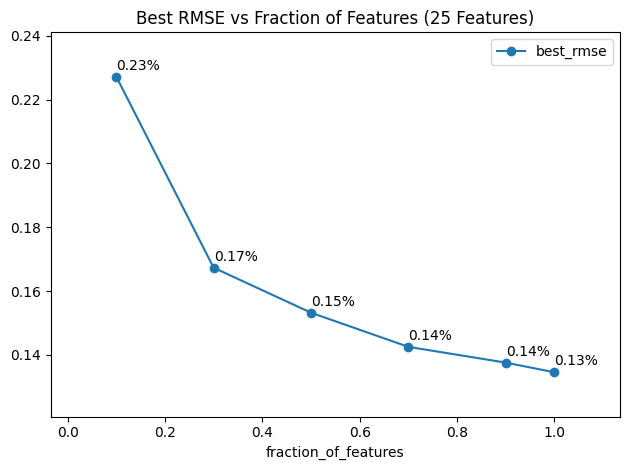

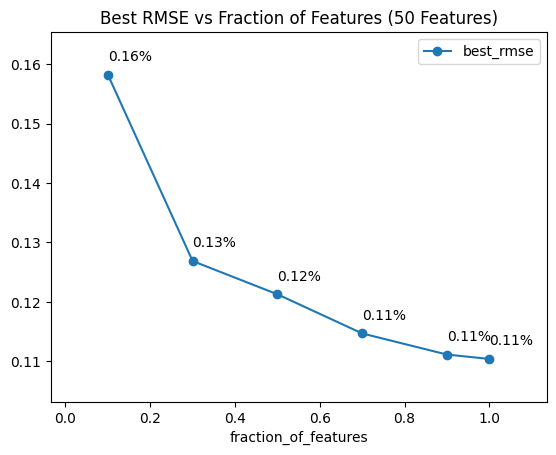

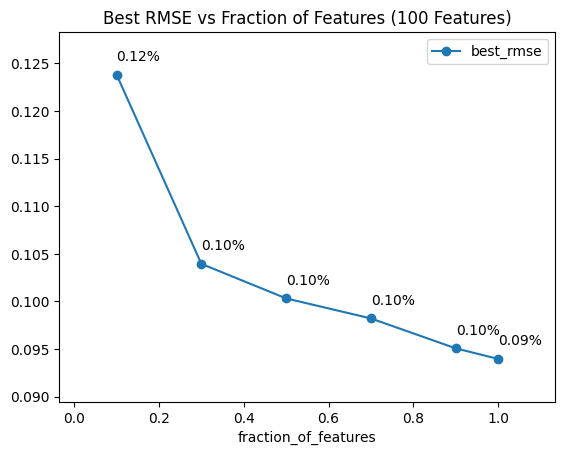

In [30]:
import matplotlib.pyplot as plt

# Plot for 25 features with annotations
fig, ax = plt.subplots()
ax.margins(0.15)
df_25.plot(
    x="fraction_of_features",
    y="best_rmse",
    kind="line",
    marker="o",
    title="Best RMSE vs Fraction of Features (25 Features)",
    ax=ax,
)
for _, row in df_25.iterrows():
    ax.annotate(
        f"{row['best_rmse']:.2f}%",
        (row["fraction_of_features"], row["best_rmse"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="left",
    )
plt.tight_layout()
plt.show()

# Plot for 50 features with annotations
fig, ax = plt.subplots()
ax.margins(0.15)
df_50.plot(
    x="fraction_of_features",
    y="best_rmse",
    kind="line",
    marker="o",
    title="Best RMSE vs Fraction of Features (50 Features)",
    ax=ax,
)
for _, row in df_50.iterrows():
    ax.annotate(
        f"{row['best_rmse']:.2f}%",
        (row["fraction_of_features"], row["best_rmse"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="left",
    )
plt.show()

# Plot for 100 features with annotations
fig, ax = plt.subplots()
ax.margins(0.15)
df_100.plot(
    x="fraction_of_features",
    y="best_rmse",
    kind="line",
    marker="o",
    title="Best RMSE vs Fraction of Features (100 Features)",
    ax=ax,
)
for _, row in df_100.iterrows():
    ax.annotate(
        f"{row['best_rmse']:.2f}%",
        (row["fraction_of_features"], row["best_rmse"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="left",
    )
plt.show()

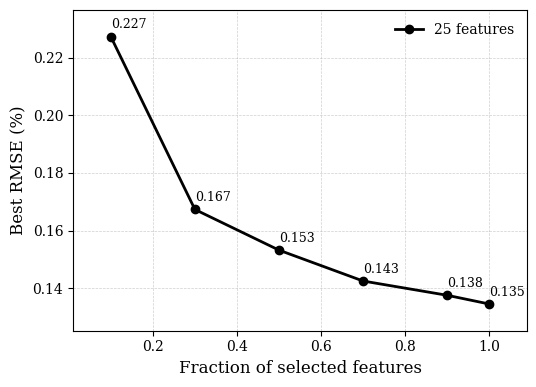

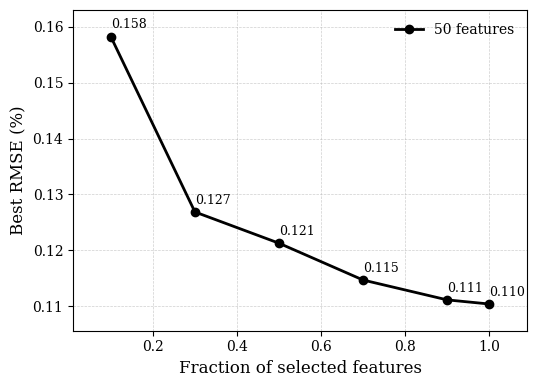

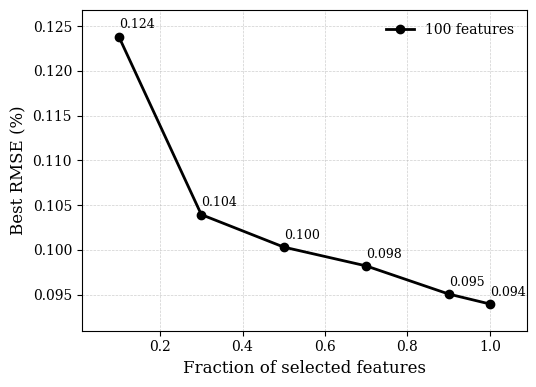

In [36]:
import matplotlib.pyplot as plt

# Global style settings (paper-ready)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "lines.markersize": 6,
})


def plot_rmse_vs_fraction(df, n_features):
    fig, ax = plt.subplots(figsize=(5.5, 4.0))  # journal-friendly size

    ax.plot(
        df["fraction_of_features"],
        df["best_rmse"],
        marker="o",
        linestyle="-",
        color="black",
        label=f"{n_features} features",
    )

    # Axis labels (preferred over long titles)
    ax.set_xlabel("Fraction of selected features")
    ax.set_ylabel("Best RMSE (%)")

    # Subtle grid
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    # Small margins to avoid crowding
    ax.margins(x=0.1, y=0.1)

    # Annotations (kept inside the axes)
    for _, row in df.iterrows():
        ax.annotate(
            f"{row['best_rmse']:.3f}",
            (row["fraction_of_features"], row["best_rmse"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="left",
            # va="bottom",
            fontsize=9,
            clip_on=True,
        )

    ax.legend(frameon=False)
    fig.tight_layout()

    return fig, ax

plot_rmse_vs_fraction(df_25, 25)
plot_rmse_vs_fraction(df_50, 50)
plot_rmse_vs_fraction(df_100, 100)
plt.show()

In [2]:
import mlflow
import pandas as pd
import re

# Load all runs, including nested ones
experiment_name = "scoring"
experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    run_view_type=mlflow.entities.ViewType.ALL
)

records = []

# Regex pattern to match: {model_name}_{num_features}_{random_id}
pattern = re.compile(r"(.+)_(\d+)_(.+)")

for _, row in runs.iterrows():
    run_name = row.get("tags.mlflow.runName", "")

    match = pattern.match(run_name)
    if not match:
        continue

    model_name = match.group(1)
    num_features = int(match.group(2))

    # rmse stored as param or metric depending on your setup
    rmse = (
        row.get("params.rmse")
        or row.get("metrics.rmse")
    )

    if rmse is None:
        continue

    records.append({
        "model_name": model_name,
        "number_of_features": num_features,
        "rmse": float(rmse)
    })

df = pd.DataFrame(records)

# Create pivot table
pivot = df.pivot_table(
    index="model_name",
    columns="number_of_features",
    values="rmse",
    aggfunc="min"   # or mean if there are duplicates
).sort_values(by=[25, 50, 100], ascending=False)

pivot


number_of_features,25,50,100
model_name,,,
RS,0.321139,0.338216,0.368346
Lasso,0.297158,0.285321,0.287791
Ridge,0.297151,0.285364,0.287796
DFA,0.223326,0.148763,0.122242
DecisionTree,0.181174,0.165783,0.158872
RandomForest,0.152450,0.132608,0.115878
XGBoost,0.139391,0.113991,0.109410
LightGBM,0.133644,0.109073,0.092629
RNN,0.121773,0.091830,0.069726


In [1]:
import mlflow
import pandas as pd
import re

# Load all runs, including nested ones
experiment_name = "scoring"
experiment = mlflow.get_experiment_by_name(experiment_name)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    run_view_type=mlflow.entities.ViewType.ALL
)

records = []

# Regex pattern to match: {model_name}_{num_features}_{random_id}
pattern = re.compile(r"(.+)_(\d+)_(.+)")

for _, row in runs.iterrows():
    run_name = row.get("tags.mlflow.runName", "")

    match = pattern.match(run_name)
    if not match:
        continue

    model_name = match.group(1)
    num_features = int(match.group(2))

    # error_std stored as param or metric depending on your setup
    error_std = (
        row.get("params.error_std")
        or row.get("metrics.error_std")
    )

    if error_std is None:
        continue

    records.append({
        "model_name": model_name,
        "number_of_features": num_features,
        "error_std": float(error_std)
    })

df = pd.DataFrame(records)

# Create pivot table
pivot = df.pivot_table(
    index="model_name",
    columns="number_of_features",
    values="error_std",
    aggfunc="min"   # or mean if there are duplicates
).sort_values(by=[25, 50, 100], ascending=False)

pivot


number_of_features,25,50,100
model_name,,,
Lasso,0.296763,0.285278,0.287787
Ridge,0.296753,0.285321,0.287792
RS,0.247854,0.229562,0.229127
DFA,0.218768,0.146828,0.120861
DecisionTree,0.180919,0.165571,0.158858
RandomForest,0.151992,0.132083,0.115862
XGBoost,0.139191,0.113919,0.109380
LightGBM,0.133478,0.108998,0.092570
RNN,0.121721,0.091830,0.065574


In [3]:
import mlflow

failed_run_id = "780827f0d3444027a2ffcfa7a60427cf"
failed_run = mlflow.get_run(failed_run_id)

mlflow.set_experiment("tune_hyperparameters")

with mlflow.start_run(run_name="RNN_50_4b691") as new_run:
    # Copy params
    for k, v in failed_run.data.params.items():
        mlflow.log_param(k, v)

    # Copy metrics
    for k, vlist in failed_run.data.metrics.items():
        mlflow.log_metric("best_rmse", vlist)

    # Add link to original
    mlflow.set_tag("original_run_id", failed_run_id)
